In [1]:
import sys
import os
sys.path.append("{}/../domain/build".format(os.getcwd()))

In [2]:
%matplotlib ipympl

In [3]:
from cornerstone import iHilbert, iHilbertMixD, hilbertIBoxKeys, hilbertMixDIBoxKeys, spanSfcRange, spanSfcRangeMixD, hilbertIBox, hilbertMixDIBox, randomCoordinates, randomCoordinatesMixD
import random
import matplotlib.pyplot as plt
import numpy as np

bx = 21
by = 21
bz = 17
max_level = 21
assert bx <= max_level and by <= max_level and bz <= max_level
nparticles = 100

In [4]:
class Box:
    def __init__(self, xmin, xmax, ymin, ymax, zmin, zmax):
        self._xmin = xmin
        self._xmax = xmax
        self._ymin = ymin
        self._ymax = ymax
        self._zmin = zmin
        self._zmax = zmax
    
    def xmin(self):
        return self._xmin
    def xmax(self):
        return self._xmax
    def ymin(self):
        return self._ymin
    def ymax(self):
        return self._ymax
    def zmin(self):
        return self._zmin
    def zmax(self):
        return self._zmax

    def __repr__(self):
        return f"Box(xmin={self._xmin}, xmax={self._xmax}, ymin={self._ymin}, ymax={self._ymax}, zmin={self._zmin}, zmax={self._zmax})"

In [5]:
random_coords_3D = randomCoordinates(nparticles, 42, bx, by, bz)
random_coords_3D_box = Box(random_coords_3D[0][0], random_coords_3D[0][1], random_coords_3D[0][2], random_coords_3D[0][3], random_coords_3D[0][4], random_coords_3D[0][5])
random_coords_3D_keys = random_coords_3D[1]
random_coords_3D_particles = [[x, y, z] for x, y, z in zip(random_coords_3D[2], random_coords_3D[3], random_coords_3D[4])]
random_coords_MixD = randomCoordinatesMixD(nparticles, 42, bx, by, bz)
random_coords_MixD_box = Box(random_coords_MixD[0][0], random_coords_MixD[0][1], random_coords_MixD[0][2], random_coords_MixD[0][3], random_coords_MixD[0][4], random_coords_MixD[0][5])
random_coords_MixD_keys = random_coords_MixD[1]
random_coords_MixD_particles = [[x, y, z] for x, y, z in zip(random_coords_MixD[2], random_coords_MixD[3], random_coords_MixD[4])]

In [6]:
def plot_particles_3d(particles):
    """
    Plots a list of particles in 3D space using matplotlib.
    
    Parameters:
    - particles: A list of particles to plot.
    """
    # Convert the list of points into separate x, y, z arrays
    x_vals, y_vals, z_vals = zip(*particles)
    
    # Plot the particles
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    max_range = max(max(x_vals) - min(x_vals), max(y_vals) - min(y_vals), max(z_vals) - min(z_vals))
    mid_x = (max(x_vals) + min(x_vals)) / 2
    mid_y = (max(y_vals) + min(y_vals)) / 2
    mid_z = (max(z_vals) + min(z_vals)) / 2

    ax.set_xlim(mid_x - max_range / 2, mid_x + max_range / 2)
    ax.set_ylim(mid_y - max_range / 2, mid_y + max_range / 2)
    ax.set_zlim(mid_z - max_range / 2, mid_z + max_range / 2)
    ax.scatter(x_vals, y_vals, z_vals, color='r')
    ax.set_title('Random Particles in 3D Space (bx = 10, by = 8, bz = 4)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

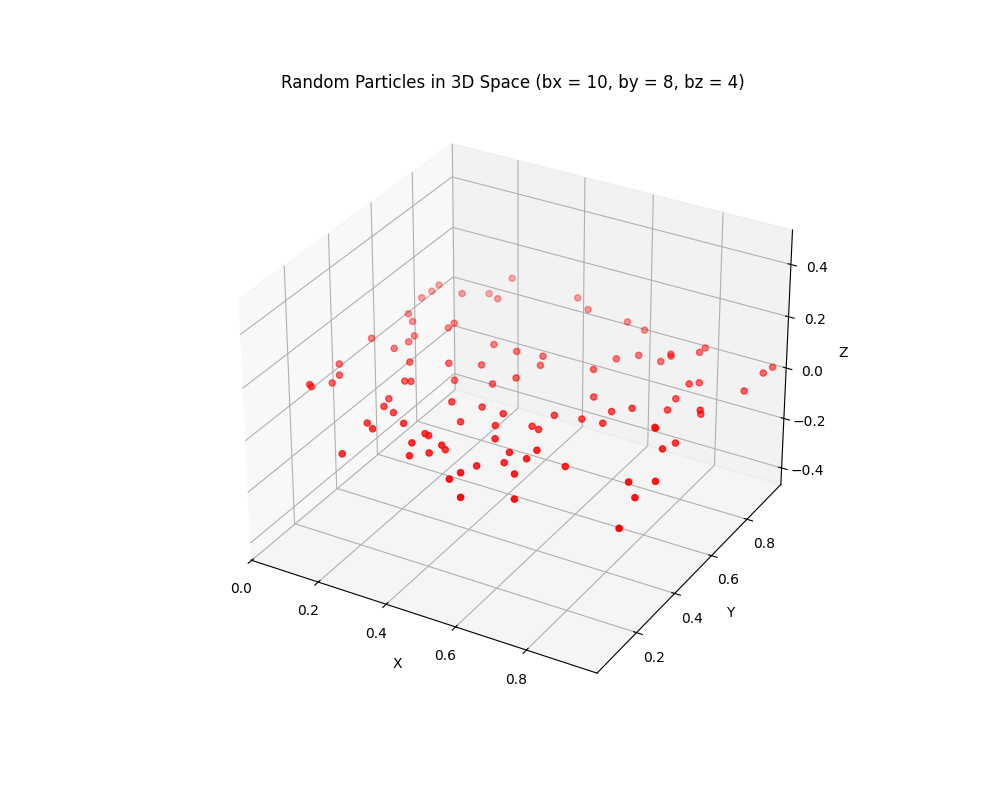

In [7]:
plot_particles_3d(random_coords_MixD_particles)

In [8]:
def plot_IBox_standalone(ibox):
    """
    Plots the IBox in 3D space using matplotlib.
    
    Parameters:
    - ibox: The IBox object to plot.
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract the min and max coordinates from the IBox
    xmin, xmax = ibox.xmin(), ibox.xmax()
    ymin, ymax = ibox.ymin(), ibox.ymax()
    zmin, zmax = ibox.zmin(), ibox.zmax()
    
    # Define the vertices of the box
    vertices = [
        [xmin, ymin, zmin],
        [xmin, ymin, zmax],
        [xmin, ymax, zmin],
        [xmin, ymax, zmax],
        [xmax, ymin, zmin],
        [xmax, ymin, zmax],
        [xmax, ymax, zmin],
        [xmax, ymax, zmax]
    ]
    
    # Define the 12 edges of the box
    edges = [
        [vertices[0], vertices[1]],
        [vertices[0], vertices[2]],
        [vertices[0], vertices[4]],
        [vertices[1], vertices[3]],
        [vertices[1], vertices[5]],
        [vertices[2], vertices[3]],
        [vertices[2], vertices[6]],
        [vertices[3], vertices[7]],
        [vertices[4], vertices[5]],
        [vertices[4], vertices[6]],
        [vertices[5], vertices[7]],
        [vertices[6], vertices[7]]
    ]
    
    # Plot the edges
    for edge in edges:
        ax.plot3D(*zip(*edge), color='b')
    
    ax.set_title('IBox in 3D Space')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

# Function to plot IBox
def plot_IBox(ax, ibox, color='b'):
    xmin, xmax = ibox.xmin(), ibox.xmax()
    ymin, ymax = ibox.ymin(), ibox.ymax()
    zmin, zmax = ibox.zmin(), ibox.zmax()
    
    vertices = [
        [xmin, ymin, zmin],
        [xmin, ymin, zmax],
        [xmin, ymax, zmin],
        [xmin, ymax, zmax],
        [xmax, ymin, zmin],
        [xmax, ymin, zmax],
        [xmax, ymax, zmin],
        [xmax, ymax, zmax]
    ]
    
    edges = [
        [vertices[0], vertices[1]],
        [vertices[0], vertices[2]],
        [vertices[0], vertices[4]],
        [vertices[1], vertices[3]],
        [vertices[1], vertices[5]],
        [vertices[2], vertices[3]],
        [vertices[2], vertices[6]],
        [vertices[3], vertices[7]],
        [vertices[4], vertices[5]],
        [vertices[4], vertices[6]],
        [vertices[5], vertices[7]],
        [vertices[6], vertices[7]]
    ]

    for edge in edges:
        ax.plot3D(*zip(*edge), color=color)


In [9]:
def scale_int_box_based_on_3D_box(box_int, box_3D):
    """
    Scales the given integer box based on the given 3D box.
    
    Parameters:
    - box_int: The integer box to scale.
    - box_3D: The 3D box to scale the integer box based on.
    
    Returns:
    - The scaled integer box.
    """
    print("Box int: (xmin={}, xmax={}, ymin={}, ymax={}, zmin={}, zmax={})".format(box_int.xmin(), box_int.xmax(), box_int.ymin(), box_int.ymax(), box_int.zmin(), box_int.zmax()))
    print("Box 3D: ", box_3D)
    # Extract the min and max coordinates from the 3D box
    xmin, xmax = box_3D.xmin(), box_3D.xmax()
    ymin, ymax = box_3D.ymin(), box_3D.ymax()
    zmin, zmax = box_3D.zmin(), box_3D.zmax()
    scale_x = (xmax - xmin) / (1 << 21)
    scale_y = (ymax - ymin) / (1 << 21)
    scale_z = (zmax - zmin) / (1 << 21)
    print("Scale x: ", scale_x)
    print("Scale y: ", scale_y)
    print("Scale z: ", scale_z)
    # Scale the integer box based on the 3D box
    return Box(
        xmin=box_int.xmin() * scale_x,
        xmax=box_int.xmax() * scale_x,
        ymin=box_int.ymin() * scale_y,
        ymax=box_int.ymax() * scale_y,
        zmin=box_int.zmin() * scale_z,
        zmax=box_int.zmax() * scale_z
    )
def scale_int_box_based_on_MixD_box(box_int, box_3D):
    """
    Scales the given integer box based on the given 3D box.
    
    Parameters:
    - box_int: The integer box to scale.
    - box_3D: The 3D box to scale the integer box based on.
    
    Returns:
    - The scaled integer box.
    """
    print("Box int: (xmin={}, xmax={}, ymin={}, ymax={}, zmin={}, zmax={})".format(box_int.xmin(), box_int.xmax(), box_int.ymin(), box_int.ymax(), box_int.zmin(), box_int.zmax()))
    print("Box 3D: ", box_3D)
    # Extract the min and max coordinates from the 3D box
    xmin, xmax = box_3D.xmin(), box_3D.xmax()
    ymin, ymax = box_3D.ymin(), box_3D.ymax()
    zmin, zmax = box_3D.zmin(), box_3D.zmax()
    scale_x = (xmax - xmin) / (1 << bx)
    scale_y = (ymax - ymin) / (1 << by)
    scale_z = (zmax - zmin) / (1 << bz)
    print("Scale x: ", scale_x)
    print("Scale y: ", scale_y)
    print("Scale z: ", scale_z)
    # Scale the integer box based on the 3D box
    return Box(
        xmin=box_int.xmin() * scale_x,
        xmax=box_int.xmax() * scale_x,
        ymin=box_int.ymin() * scale_y,
        ymax=box_int.ymax() * scale_y,
        zmin=box_int.zmin() * scale_z,
        zmax=box_int.zmax() * scale_z
    )

In [10]:
def set_ax_axes(ax, boxes):
    # Find min and max edges for all the boxes
    min_x = min(box.xmin() for box in boxes.values())
    max_x = max(box.xmax() for box in boxes.values())
    min_y = min(box.ymin() for box in boxes.values())
    max_y = max(box.ymax() for box in boxes.values())
    min_z = min(box.zmin() for box in boxes.values())
    max_z = max(box.zmax() for box in boxes.values())

    max_edge = max(max_x - min_x, max_y - min_y, max_z - min_z)
    mid_x = (max_x + min_x) / 2
    mid_y = (max_y + min_y) / 2
    mid_z = (max_z + min_z) / 2

    ax.set_xlim(mid_x - max_edge / 2, mid_x + max_edge / 2)
    ax.set_ylim(mid_y - max_edge / 2, mid_y + max_edge / 2)
    ax.set_zlim(mid_z - max_edge / 2, mid_z + max_edge / 2)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x / 1e8:.1f}'))
    # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y / 1e8:.1f}'))
    # ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda z, _: f'{z / 1e8:.1f}'))
    

<class 'cornerstone.IBox'>
Box int: (xmin=458752, xmax=524288, ymin=131072, ymax=196608, zmin=65536, zmax=131072)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  2.9802322387695312e-08
<class 'cornerstone.IBox'>
Box int: (xmin=917504, xmax=983040, ymin=393216, ymax=458752, zmin=0, zmax=65536)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  2.9802322387695312e-08
<class 'cornerstone.IBox'>
Box int: (xmin=65536, xmax=131072, ymin=720896, ymax=786432, zmin=131072, zmax=196608)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  2.9802322387695312e-08
<class 'cornerstone.IBox'>
Box int: (xmin=393216, xmax=458752, ymin=720896, ymax=786432, zmin=131072, zmax=196608)
Box 3D:  Box(xmin=0.0, xmax=1.0, ym

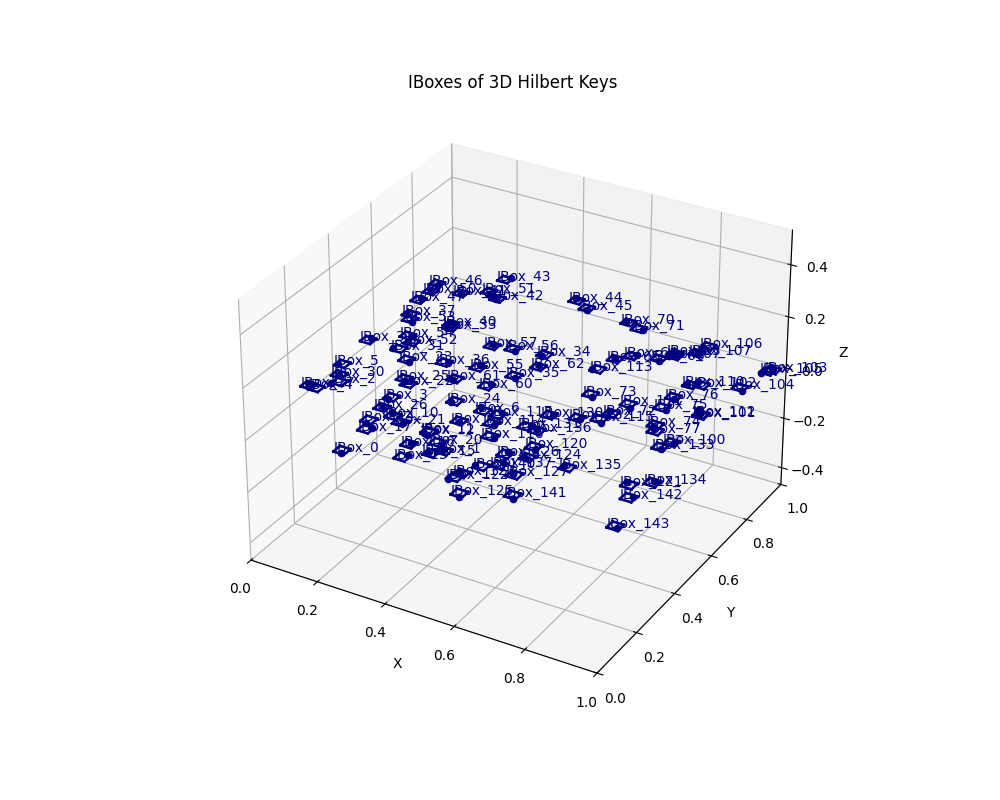

Box int: (xmin=458752, xmax=524288, ymin=393216, ymax=458752, zmin=65536, zmax=131072)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  4.76837158203125e-07
Box int: (xmin=458752, xmax=524288, ymin=131072, ymax=196608, zmin=0, zmax=65536)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  4.76837158203125e-07
Box int: (xmin=786432, xmax=851968, ymin=196608, ymax=262144, zmin=0, zmax=65536)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  4.76837158203125e-07
Box int: (xmin=786432, xmax=851968, ymin=262144, ymax=327680, zmin=65536, zmax=131072)
Box 3D:  Box(xmin=0.0, xmax=1.0, ymin=0.0, ymax=1.0, zmin=0.0, zmax=0.0625)
Scale x:  4.76837158203125e-07
Scale y:  4.76837158203125e-07
Scale z:  4.76837

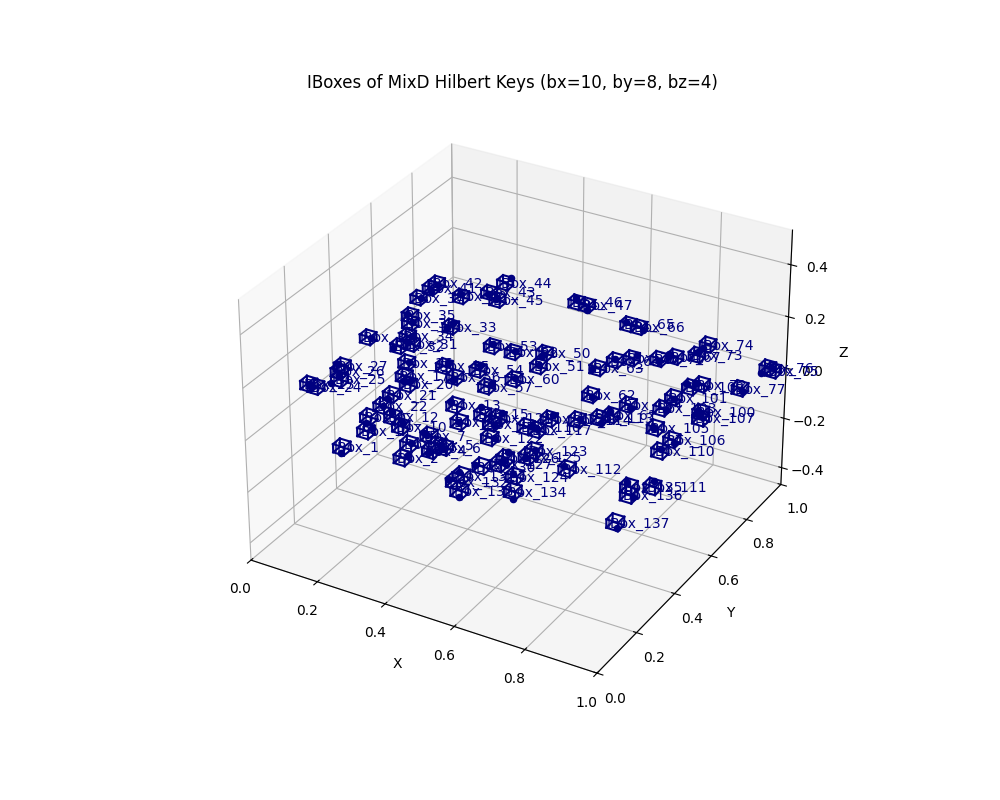

In [14]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
level = 5
# Plot specific particles
indices_to_plot = list(range(len(random_coords_3D_particles)))
# indices_to_plot = [0, 49, 99, 149]
colors = plt.cm.jet(np.linspace(0, 1, 8**level))
box_3D_map = {}
for idx in indices_to_plot:
    particle = random_coords_3D_particles[idx]
    particle_key = random_coords_3D_keys[idx]
    print(type(hilbertIBox(int(particle_key), int(level))))
    box = scale_int_box_based_on_3D_box(hilbertIBox(particle_key, level), random_coords_3D_box)
    box_key = (box.xmin(), box.xmax(), box.ymin(), box.ymax(), box.zmin(), box.zmax())
    if not box_key in box_3D_map:
        box_3D_map[box_key] = box
        color = colors[list(box_3D_map.keys()).index(box_key)]
        # plot_IBox(ax, box, color=color)
        # ax.text(box.xmin(), box.ymin(), box.zmin(), f'IBox_{oct(len(box_3D_map)-1)[2:]}', color=color)
    ax.scatter(*particle, color=color)#, label=f'Particle {idx}')


for box_key, box in box_3D_map.items():
    index = list(box_3D_map.keys()).index(box_key)
    color = colors[index]
    plot_IBox(ax, box, color=color)
    ax.text(box.xmin(), box.ymin(), box.zmin(), f'IBox_{oct(index)[2:]}', color=color)

set_ax_axes(ax, box_3D_map)

print("3D box map size: ", len(box_3D_map))
ax.set_title('IBoxes of 3D Hilbert Keys')
# ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
box_MixD_map = {}
for idx in indices_to_plot:
    particle = random_coords_MixD_particles[idx]
    particle_key = random_coords_MixD_keys[idx]
    box = scale_int_box_based_on_MixD_box(hilbertMixDIBox(particle_key, max_level - level, bx, by, bz), random_coords_3D_box)
    box_key = (box.xmin(), box.xmax(), box.ymin(), box.ymax(), box.zmin(), box.zmax())
    if not box_key in box_MixD_map:
        box_MixD_map[box_key] = box
        color = colors[list(box_MixD_map.keys()).index(box_key)]
        # plot_IBox(ax, box, color=color)
        # ax.text(box.xmin(), box.ymin(), box.zmin(), f'IBox_{oct(len(box_MixD_map)-1)[2:]}', color=color)
    ax.scatter(*particle, color=color)#, label=f'Particle {idx}')

for box_key, box in box_MixD_map.items():
    index = list(box_MixD_map.keys()).index(box_key)
    color = colors[index]
    plot_IBox(ax, box, color=color)
    ax.text(box.xmin(), box.ymin(), box.zmin(), f'IBox_{oct(index)[2:]}', color=color)

set_ax_axes(ax, box_MixD_map)

print("MixD box map size: ", len(box_MixD_map))
ax.set_title('IBoxes of MixD Hilbert Keys (bx=10, by=8, bz=4)')
# ax.legend()
plt.show()

In [13]:
from cornerstone import decodeHilbertMixD
octal_string = '0o20000000000000000'
decimal_value = int(octal_string, 8)
print(decimal_value)
print(type(decimal_value), type(bx), type(by), type(bz))
print(type(decodeHilbertMixD))
ix, iy, iz = decodeHilbertMixD(decimal_value, bx, by, bz)
print(ix, iy, iz)

562949953421312
<class 'int'> <class 'int'> <class 'int'> <class 'int'>
<class 'nanobind.nb_func'>
0 65536 65536
bits: 21 21 17
key_2D (octal): 0
key_3D before mask_2D (octal): 0000000000000010000000000000000000000000000000000000000000000000
mask_2D: 0000000000000000000000000000000000000000000001111111111111111111
key_3D (octal): 20000000000000000
